In [1]:
import pandas as pd
import numpy as np

In [18]:
from imodels import get_clean_dataset
from sklearn.model_selection import train_test_split
X, y, colnames = get_clean_dataset("iai_pecarn_pred")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [19]:
# read in shap and lime dfs
shap_df = pd.read_csv("results/shap.csv", header=None)
lime_df = pd.read_csv("results/lime.csv", header=None)
lmdi_plus_df = pd.read_csv("results/lmdi_plus.csv", header=None)

In [20]:
# get subset of observations that are above and below 2 years old (col 20 is indicator for below 2)
shap_above_2 = shap_df[X_test[:,20] == 0]
shap_below_2 = shap_df[X_test[:,20] == 1]
lime_above_2 = lime_df[X_test[:,20] == 0]
lime_below_2 = lime_df[X_test[:,20] == 1]
lmdi_plus_above_2 = lmdi_plus_df[X_test[:,20] == 0]
lmdi_plus_below_2 = lmdi_plus_df[X_test[:,20] == 1]

Text(1583.6633986928105, 0.5, 'Samples')

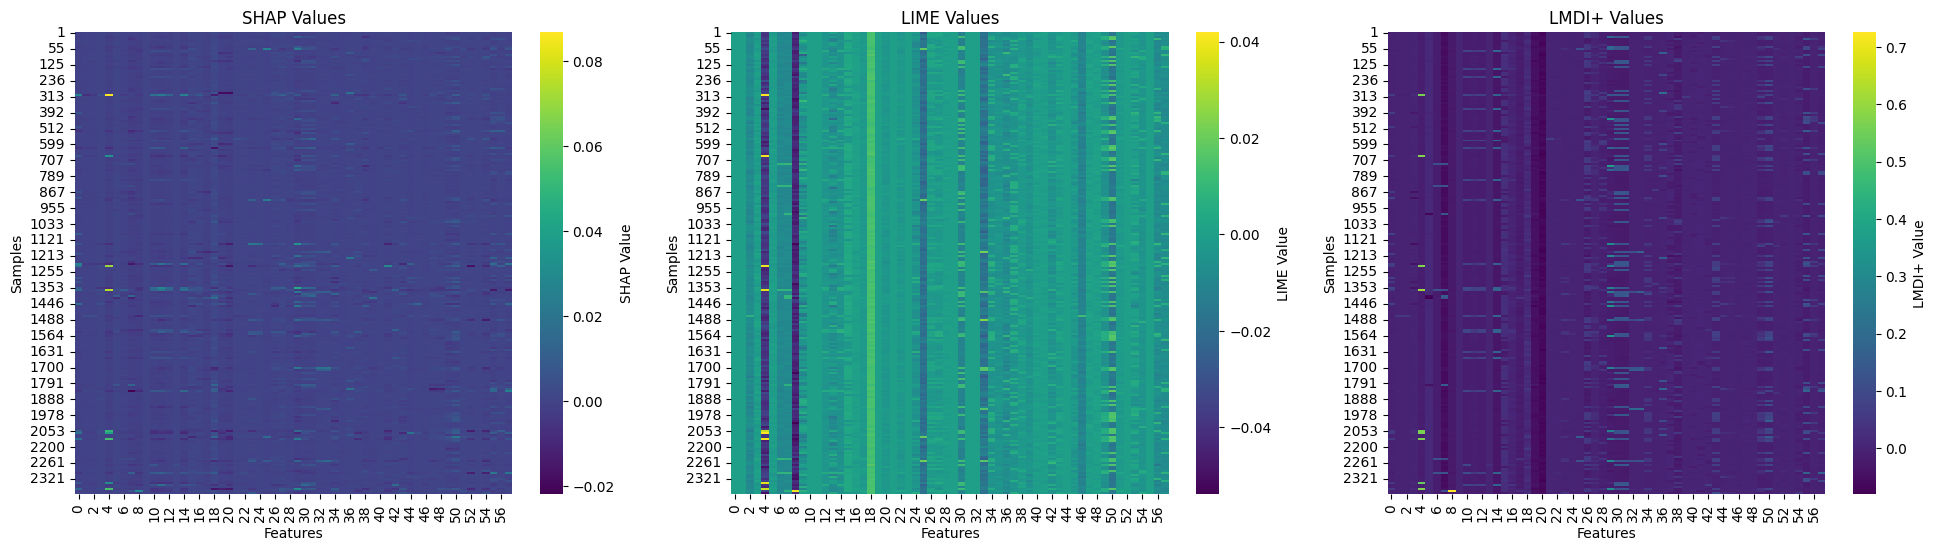

In [24]:
# plot heatmaps
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(24, 6))
plt.subplot(1, 3, 1)
sns.heatmap(shap_below_2, cmap="viridis", cbar_kws={'label': 'SHAP Value'})
plt.title("SHAP Values")
plt.xlabel("Features")
plt.ylabel("Samples")
plt.subplot(1, 3, 2)
sns.heatmap(lime_below_2, cmap="viridis", cbar_kws={'label': 'LIME Value'})
plt.title("LIME Values")
plt.xlabel("Features")
plt.ylabel("Samples")
plt.subplot(1, 3, 3)
sns.heatmap(lmdi_plus_below_2, cmap="viridis", cbar_kws={'label': 'LMDI+ Value'})
plt.title("LMDI+ Values")
plt.xlabel("Features")
plt.ylabel("Samples")

Text(1583.6633986928105, 0.5, 'Samples')

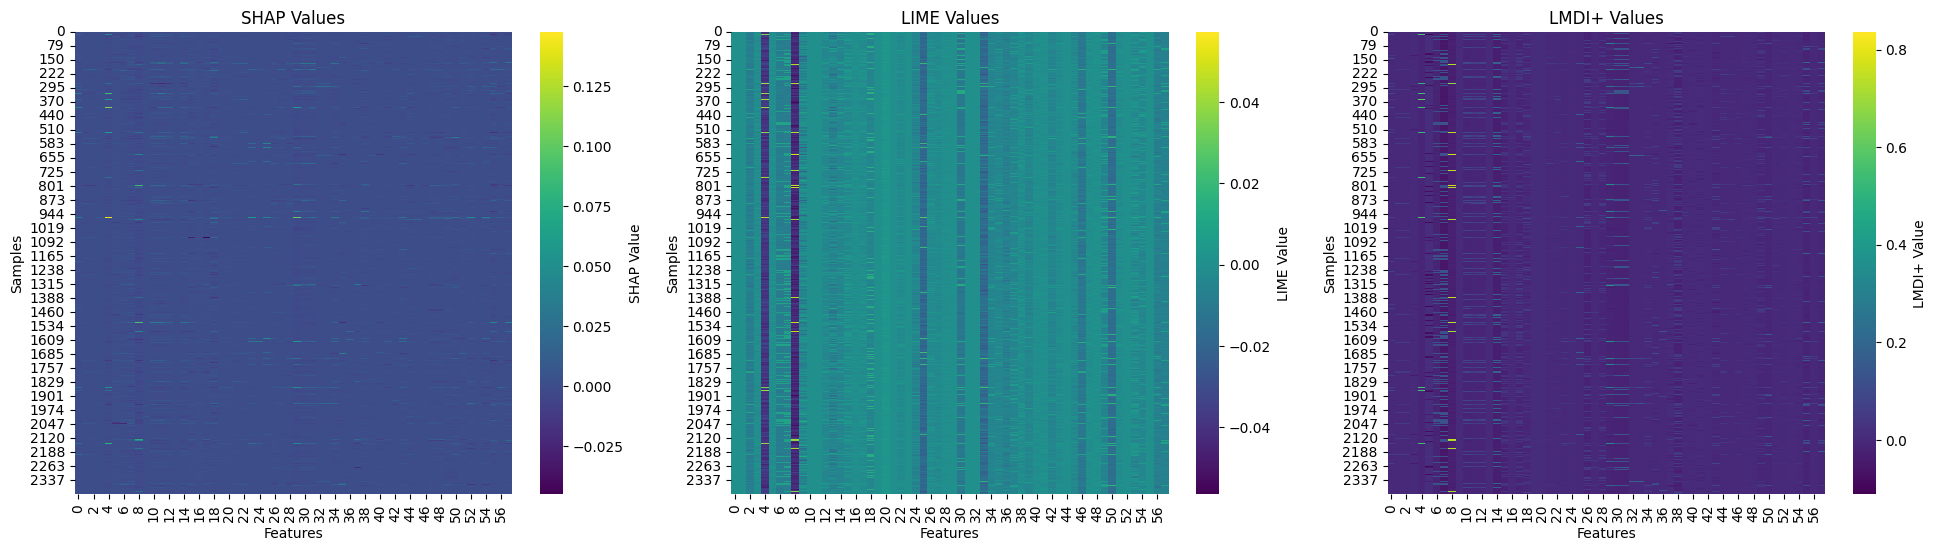

In [23]:
# plot heatmaps
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(24, 6))
plt.subplot(1, 3, 1)
sns.heatmap(shap_above_2, cmap="viridis", cbar_kws={'label': 'SHAP Value'})
plt.title("SHAP Values")
plt.xlabel("Features")
plt.ylabel("Samples")
plt.subplot(1, 3, 2)
sns.heatmap(lime_above_2, cmap="viridis", cbar_kws={'label': 'LIME Value'})
plt.title("LIME Values")
plt.xlabel("Features")
plt.ylabel("Samples")
plt.subplot(1, 3, 3)
sns.heatmap(lmdi_plus_above_2, cmap="viridis", cbar_kws={'label': 'LMDI+ Value'})
plt.title("LMDI+ Values")
plt.xlabel("Features")
plt.ylabel("Samples")

In [32]:
# get the 100 rows of lmdi and shap that are least similar
shap_above_2_rankings = shap_above_2.rank(axis=1)
lmdi_plus_above_2_rankings = lmdi_plus_above_2.rank(axis=1)
rank_diff = (shap_above_2_rankings - lmdi_plus_above_2_rankings).abs().sum(axis=1)
# get 100 most different rankings
most_diff_idx = rank_diff.nlargest(100).index
shap_most_diff_above_2 = shap_above_2.iloc[most_diff_idx]
lmdi_plus_most_diff_above_2 = lmdi_plus_above_2.iloc[most_diff_idx]

IndexError: positional indexers are out-of-bounds

In [30]:
# get the rows of lmdi and shap that are least similar
shap_below_2_rankings = shap_below_2.rank(axis=1)
lmdi_plus_below_2_rankings = lmdi_plus_below_2.rank(axis=1)
rank_diff = (shap_below_2_rankings - lmdi_plus_below_2_rankings).abs().sum(axis=1)
most_diff_idx = rank_diff.idxmax()
shap_most_diff_below_2 = shap_below_2.iloc[most_diff_idx]
lmdi_plus_most_diff_below_2 = lmdi_plus_below_2.iloc[most_diff_idx]

IndexError: single positional indexer is out-of-bounds

Text(120.72222222222221, 0.5, 'Sample')

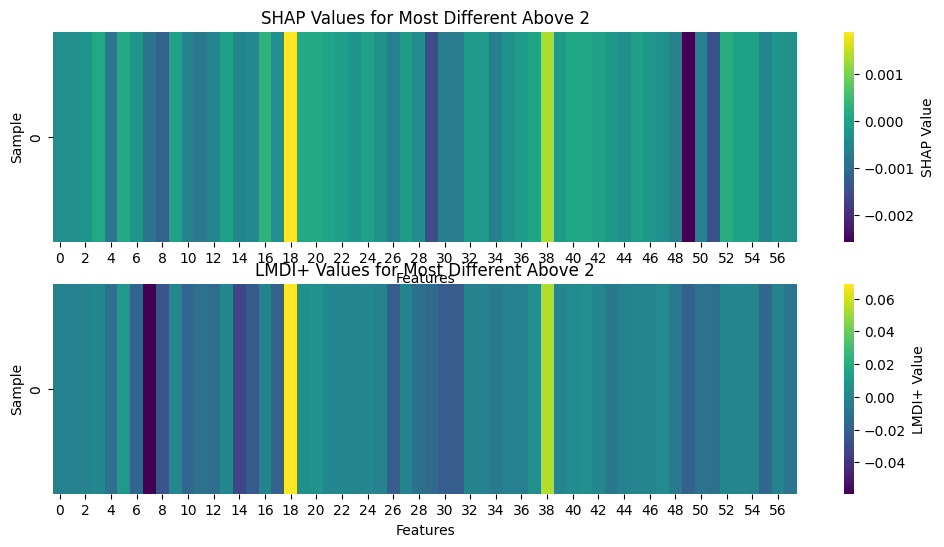

In [28]:
# heatmap the two shap_diff and lmdi_plus_most_diff
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
sns.heatmap(shap_most_diff_above_2.values.reshape(1, -1), cmap="viridis", cbar_kws={'label': 'SHAP Value'})
plt.title("SHAP Values for Most Different Above 2")
plt.xlabel("Features")
plt.ylabel("Sample")
plt.subplot(2, 1, 2)
sns.heatmap(lmdi_plus_most_diff_above_2.values.reshape(1, -1), cmap="viridis", cbar_kws={'label': 'LMDI+ Value'})
plt.title("LMDI+ Values for Most Different Above 2")
plt.xlabel("Features")
plt.ylabel("Sample")    

In [3]:
# get column ranks for each, with 1 being highest value in the row and n being lowest
shap_ranked = shap_df.rank(1, ascending=False)
lime_ranked = lime_df.rank(1, ascending=False)
lmdi_plus_ranked = lmdi_plus_df.rank(1, ascending=False)

In [4]:
shap_lime_diff = shap_ranked - lime_ranked
lmdi_plus_shap_diff = lmdi_plus_ranked - shap_ranked
lmdi_plus_lime_diff = lmdi_plus_ranked - lime_ranked

In [5]:
# take row sums of the differences
shap_lime_row_sums = shap_lime_diff.abs().sum(axis=1)
lmdi_plus_shap_row_sums = lmdi_plus_shap_diff.abs().sum(axis=1)
lmdi_plus_lime_row_sums = lmdi_plus_lime_diff.abs().sum(axis=1)

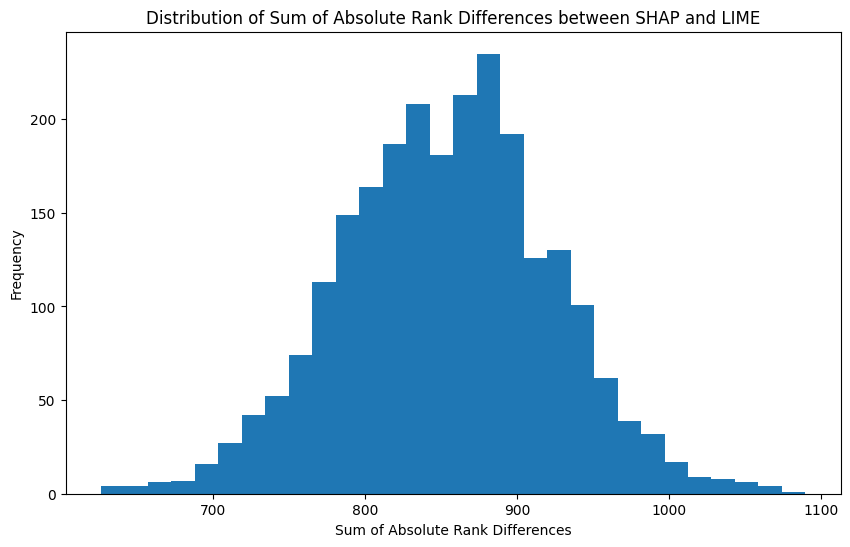

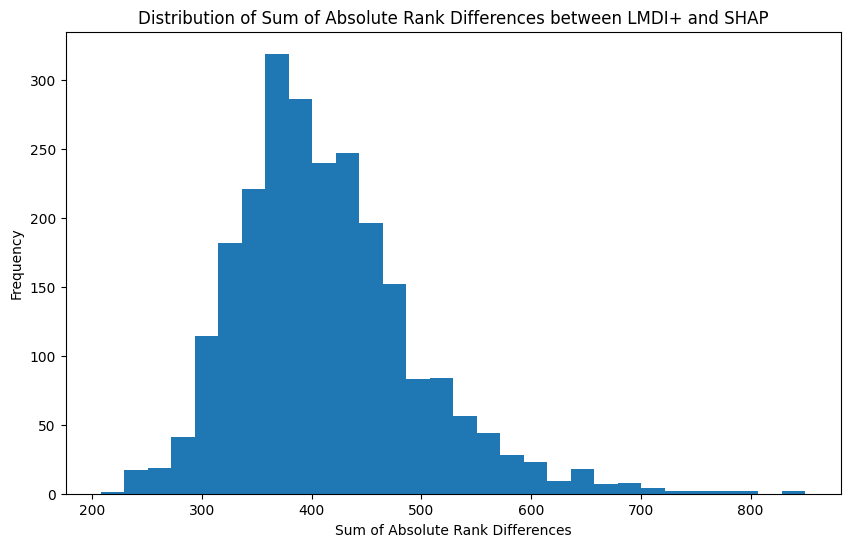

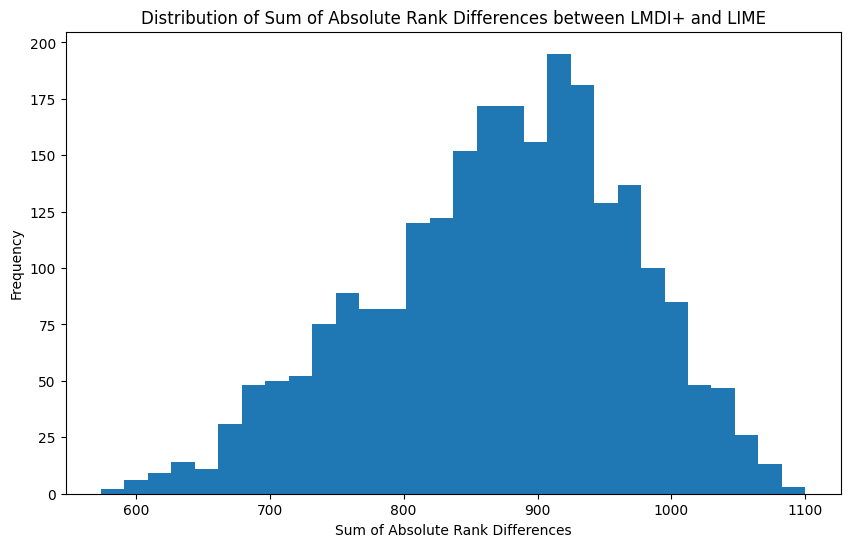

In [6]:
# plot distribution of row sums
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.hist(shap_lime_row_sums, bins=30)
plt.xlabel("Sum of Absolute Rank Differences")
plt.ylabel("Frequency")
plt.title("Distribution of Sum of Absolute Rank Differences between SHAP and LIME")
plt.show()

plt.figure(figsize=(10,6))
plt.hist(lmdi_plus_shap_row_sums, bins=30)
plt.xlabel("Sum of Absolute Rank Differences")
plt.ylabel("Frequency")
plt.title("Distribution of Sum of Absolute Rank Differences between LMDI+ and SHAP")
plt.show()

plt.figure(figsize=(10,6))
plt.hist(lmdi_plus_lime_row_sums, bins=30)
plt.xlabel("Sum of Absolute Rank Differences")
plt.ylabel("Frequency")
plt.title("Distribution of Sum of Absolute Rank Differences between LMDI+ and LIME")
plt.show()

In [14]:
shap_df.shape

(2409, 58)